OM - Desafio 1 - Sala Cirurgica.ipynb

Automatically generated by Colab.

Original file is located at
    https://colab.research.google.com/drive/1KrDf-uEVsyjW8cyz7BP9sPk21YYISZqV

---
## **Curso**: Residência em Inteligência Artificial
## **Unidade Curricular**: Otimização e Meta-Heurísticas
## **Professor**: Matheus Vanzan
## **Desafio: Otimização da Alocação de Salas Cirúrgicas**
---

Uma divisão hospitalar possui um recurso extremamente limitado: **horas semanais de sala cirúrgica**.

Essas horas precisam ser distribuídas entre diferentes cirurgiões. O problema é que os profissionais apresentam produtividades financeiras diferentes, medidas pela receita gerada por hora de utilização da sala.

Historicamente, a distribuição das horas era fortemente influenciada pelo uso anterior da sala. Entretanto, essa política não necessariamente direciona o recurso para os profissionais que geram maior retorno por hora.

Neste desafio, você deverá utilizar **Programação Linear** para propor uma nova distribuição das horas disponíveis, respeitando as regras operacionais da divisão e buscando **maximizar a receita profissional semanal**.

A dificuldade principal deste desafio não está em chamar o solver. Você deverá **traduzir o problema descrito em linguagem de negócio para um modelo matemático**, identificando corretamente variáveis de decisão, função objetivo e restrições.

## Referência do estudo de caso

O desafio é uma **adaptação didática** de um estudo publicado com dados da Divisão de Cirurgia Geral do Duke University Medical Center:

> **KUO, Paul C.; SCHROEDER, Rebecca A.; MAHAFFEY, Samuel; BOLLINGER, R. Randall.**  
> *Optimization of Operating Room Allocation Using Linear Programming Techniques.*  
> Journal of the American College of Surgeons, v. 197, n. 6, p. 889–895, 2003.  
> DOI: https://doi.org/10.1016/j.jamcollsurg.2003.07.006

No artigo, os autores utilizaram Programação Linear para redistribuir um recurso escasso, o tempo de sala cirúrgica, com o objetivo de maximizar a receita profissional. O estudo reportou um potencial de aumento de aproximadamente **15% na receita semanal** em relação à alocação histórica.

> **Importante:** o modelo usado neste notebook é uma versão simplificada e adaptada para fins didáticos. Portanto, o resultado numérico obtido no desafio **não precisa reproduzir exatamente** o valor publicado no artigo.

## O problema

A divisão possui **20 cirurgiões** e um total de **305,6 horas de sala cirúrgica disponíveis por semana**.

Para cada cirurgião, foi estimada uma medida de **produtividade financeira por hora de sala**, baseada nos dados apresentados no estudo original.

A nova alocação deve respeitar as seguintes regras:

1. **Todas as 305,6 horas disponíveis devem ser alocadas.**
2. Os cirurgiões de transplante `4`, `17`, `21` e `24` possuem uma carga semanal fixa de **12 horas** nesta versão didática do problema.
3. Os demais cirurgiões podem receber entre **8 e 31 horas por semana**.
4. Nenhum cirurgião pode receber uma quantidade negativa de horas.
5. O objetivo é encontrar a distribuição que **maximize a receita profissional semanal estimada**.

A receita semanal histórica da divisão, usada como referência para comparação, é de **207.700 unidades monetárias normalizadas**.

## Objetivos

Ao final do desafio, você deve ser capaz de:

1. interpretar um problema real de alocação de recursos;
2. identificar as **variáveis de decisão** necessárias;
3. formular matematicamente a **função objetivo**;
4. transformar regras operacionais em **restrições lineares**;
5. implementar o modelo utilizando **Pyomo**;
6. resolver o problema utilizando o **GLPK**;
7. validar se a solução encontrada respeita todas as restrições;
8. comparar a solução otimizada com a situação histórica;
9. interpretar criticamente o resultado do modelo.

## Tarefas obrigatórias

### 1) Analisar os dados

Explore os dados fornecidos e identifique:

- quantos cirurgiões existem;
- quais possuem maior e menor produtividade por hora;
- quais pertencem ao grupo de transplante;
- qual é a quantidade total de horas disponível.

### 2) Formular matematicamente o problema

Antes de implementar o modelo, escreva em uma célula Markdown:

- a variável ou as variáveis de decisão;
- a função objetivo;
- todas as restrições necessárias;
- o domínio das variáveis.

**Não comece pelo código.** A formulação matemática faz parte da avaliação do desafio.

### 3) Implementar o modelo no Pyomo

Implemente a formulação criada na etapa anterior utilizando Pyomo.

### 4) Resolver utilizando GLPK

Execute o solver e verifique o status da solução.

### 5) Validar a solução

Mostre explicitamente que:

- a soma das horas alocadas é igual a `305.6`;
- os cirurgiões de transplante receberam a carga definida;
- nenhum dos demais cirurgiões violou seus limites mínimo e máximo.

### 6) Analisar a nova alocação

Construa uma tabela contendo, no mínimo:

- ID do cirurgião;
- produtividade por hora;
- horas alocadas;
- receita estimada;
- situação da alocação (`mínimo`, `máximo`, `fixo` ou `intermediário`).

Ordene a tabela de forma que seja possível analisar a relação entre produtividade e quantidade de horas recebida.

### 7) Comparar com o histórico

Calcule:

- receita semanal otimizada;
- diferença absoluta para a receita histórica;
- ganho percentual em relação à receita histórica.

Produza também uma visualização comparando **receita histórica x receita otimizada**.

### 8) Análise crítica

Responda:

1. Por que os cirurgiões mais produtivos tendem a receber mais horas na solução?
2. Por que alguns cirurgiões permanecem com poucas horas mesmo existindo um objetivo de maximização de receita?
3. Qual é o papel das restrições na solução encontrada?
4. O artigo original reportou aproximadamente 15% de ganho. Seu resultado foi igual? Se não, explique por que uma adaptação do modelo pode produzir outro valor.
5. Cite pelo menos **duas limitações** de utilizar esse modelo como regra real de gestão hospitalar.

## Entrega

Entregue **um único notebook executável do início ao fim**, contendo:

- formulação matemática completa;
- implementação em Pyomo;
- solução obtida com GLPK;
- validação das restrições;
- tabela final de alocação;
- comparação com o histórico;
- gráfico solicitado;
- respostas da análise crítica;
- uma conclusão curta, de aproximadamente **5 a 10 linhas**, sintetizando os principais resultados.

# 0 - Setup

In [1]:
%matplotlib inline

!apt-get install -y -qq glpk-utils
!pip install -q pyomo

import pandas as pd
import matplotlib.pyplot as plt
import pyomo.environ as pyo

# 1 - Dados do problema

Os dados abaixo são fornecidos para que o foco do desafio esteja na **modelagem e na análise da solução**.

A produtividade representa uma medida normalizada de receita gerada por hora de sala cirúrgica.

In [2]:
productivity = {
    1: 724,
    2: 644,
    4: 779,
    6: 704,
    7: 766,
    8: 905,
    9: 657,
    10: 561,
    12: 472,
    13: 678,
    14: 368,
    15: 1381,
    16: 1186,
    17: 870,
    18: 634,
    19: 888,
    21: 427,
    23: 634,
    24: 801,
    25: 656,
}

surgeons = list(productivity.keys())

total_available_hours = 305.6

transplant_surgeons = [4, 17, 21, 24]

variable_surgeons = [
    1, 2, 6, 7, 8, 9, 10, 12,
    13, 14, 15, 16, 18, 19, 23, 25,
]

historical_revenue = 207700

## 1.1 - Análise inicial

Explore os dados antes de criar o modelo.

Mostre pelo menos:

- quantidade de cirurgiões;
- estatísticas descritivas da produtividade;
- cinco cirurgiões mais produtivos;
- cinco cirurgiões menos produtivos.

In [3]:
df_produtividade = pd.DataFrame({
    'cirurgiao': surgeons,
    'produtividade': [productivity[i] for i in surgeons],
})
df_produtividade['grupo'] = df_produtividade['cirurgiao'].apply(
    lambda i: 'transplante' if i in transplant_surgeons else 'variável'
)

print(f"Quantidade de cirurgiões: {len(surgeons)}")
print(f"Horas totais disponíveis: {total_available_hours}")
print(f"Cirurgiões do grupo de transplante (carga fixa): {transplant_surgeons}")

print("\nEstatísticas descritivas da produtividade (R$/hora):")
print(df_produtividade['produtividade'].describe())

print("\n5 cirurgiões mais produtivos:")
print(df_produtividade.sort_values('produtividade', ascending=False).head(5).to_string(index=False))

print("\n5 cirurgiões menos produtivos:")
print(df_produtividade.sort_values('produtividade').head(5).to_string(index=False))

Quantidade de cirurgiões: 20
Horas totais disponíveis: 305.6
Cirurgiões do grupo de transplante (carga fixa): [4, 17, 21, 24]

Estatísticas descritivas da produtividade (R$/hora):
count      20.000000
mean      736.750000
std       237.617533
min       368.000000
25%       634.000000
50%       691.000000
75%       818.250000
max      1381.000000
Name: produtividade, dtype: float64

5 cirurgiões mais produtivos:
 cirurgiao  produtividade       grupo
        15           1381    variável
        16           1186    variável
         8            905    variável
        19            888    variável
        17            870 transplante

5 cirurgiões menos produtivos:
 cirurgiao  produtividade       grupo
        14            368    variável
        21            427 transplante
        12            472    variável
        10            561    variável
        23            634    variável


20 cirurgiões, produtividade de R\$368 a R\$1.381 por hora (média 736,75, mediana 691). Os cirurgiões 17 e 21, ambos do grupo de transplante, já aparecem nos extremos (870 e 427) - mas os dois vão receber a mesma carga fixa de 12h, já que esse grupo fica de fora da lógica de maximização.

# 2 - Formulação matemática

Escreva abaixo a formulação matemática completa do problema.

Sua formulação deve deixar claro:

- o significado da variável de decisão;
- a função objetivo;
- a restrição de disponibilidade total;
- as regras dos dois grupos de cirurgiões;
- o domínio da variável.

### Sua formulação

**Variável de decisão:** $x_i \geq 0$, horas de sala cirúrgica alocadas por semana ao cirurgião $i$.

**Função objetivo (maximizar receita):** $Z = \sum_i p_i x_i$, onde $p_i$ é a produtividade do cirurgião $i$.

**Restrições:**
* $\sum_i x_i = 305{,}6$ (regra 1, disponibilidade total)
* $x_i = 12$ para $i \in \{4, 17, 21, 24\}$ (regra 2, grupo de transplante)
* $8 \leq x_i \leq 31$ para os demais (regra 3)

**Domínio:** $x_i \in \mathbb{R}_{\geq 0}$ - horas são contínuas, não há motivo pra exigir inteiro aqui (diferente do Notebook 3).

# 3 - Implementação no Pyomo

Implemente exatamente o modelo que você formulou.

Não altere os dados fornecidos para obter uma solução desejada.

In [4]:
modelo = pyo.ConcreteModel()

def limites_horas(modelo, i):
    if i in transplant_surgeons:
        return (12, 12)
    return (8, 31)

modelo.x = pyo.Var(surgeons, domain=pyo.NonNegativeReals, bounds=limites_horas)
x = modelo.x

Uma variável por cirurgião. Os limites dos dois grupos entram como `bounds`, igual no problema do Sítio (Notebook 2), em vez de Constraints separadas.

In [5]:
modelo.receita = pyo.Objective(
    expr=sum(productivity[i] * x[i] for i in surgeons),
    sense=pyo.maximize
)

Receita total: produtividade vezes horas alocadas, somada pra todos os cirurgiões.

In [6]:
modelo.total_horas = pyo.Constraint(
    expr=sum(x[i] for i in surgeons) == total_available_hours
)

Restrição de igualdade, não de teto: todas as 305,6h precisam ser distribuídas (regra 1).

# 4 - Resolução com GLPK

Resolva o problema e mostre:

- status retornado pelo solver;
- condição de término;
- valor da função objetivo.

In [7]:
solver = pyo.SolverFactory('glpk')
resultado = solver.solve(modelo)

print(f"Status da solução: {resultado.solver.status}")
print(f"Condição de término: {resultado.solver.termination_condition}")
print(f"Bound inferior: {resultado.problem.lower_bound}")
print(f"Bound superior: {resultado.problem.upper_bound}")
print(f"Valor ótimo da função objetivo: R$ {pyo.value(modelo.receita):.2f}")

Status da solução: ok
Condição de término: optimal
Bound inferior: 257856.4
Bound superior: 257856.4
Valor ótimo da função objetivo: R$ 257856.40


Status ok, optimal. Bound inferior e superior batem em R\$257.856,40 - como no Notebook 2, PL puro dá certeza do ótimo, sem margem de incerteza.

# 5 - Validação da solução

Uma solução numérica não deve ser aceita sem validação.

Verifique programaticamente se todas as regras do problema foram respeitadas.

In [8]:
import math

soma_horas = sum(pyo.value(x[i]) for i in surgeons)
print(f"Soma das horas alocadas: {soma_horas:.4f} (esperado: {total_available_hours})")
assert math.isclose(soma_horas, total_available_hours, abs_tol=1e-6), "Soma de horas não bate com o total disponível"

print("\nCirurgiões de transplante (esperado: 12h fixas):")
for i in transplant_surgeons:
    h = pyo.value(x[i])
    print(f"  Cirurgião {i}: {h:.4f}h")
    assert math.isclose(h, 12, abs_tol=1e-6), f"Cirurgião {i} não recebeu a carga fixa de 12h"

print("\nCirurgiões variáveis (esperado: entre 8h e 31h):")
violacoes = [i for i in variable_surgeons if not (8 - 1e-6 <= pyo.value(x[i]) <= 31 + 1e-6)]
print(f"  Violações de limite: {violacoes if violacoes else 'nenhuma'}")
assert not violacoes, "Existe cirurgião fora dos limites [8, 31]"

print("\nTodas as validações passaram.")

Soma das horas alocadas: 305.6000 (esperado: 305.6)

Cirurgiões de transplante (esperado: 12h fixas):
  Cirurgião 4: 12.0000h
  Cirurgião 17: 12.0000h
  Cirurgião 21: 12.0000h
  Cirurgião 24: 12.0000h

Cirurgiões variáveis (esperado: entre 8h e 31h):
  Violações de limite: nenhuma

Todas as validações passaram.


Soma bateu em 305,6h, os 4 cirurgiões de transplante ficaram nas 12h fixas e nenhum do grupo variável violou os limites - os três `assert` passaram.

# 6 - Análise da alocação

Construa uma tabela final que facilite a interpretação da solução.

A tabela deve conter:

- cirurgião;
- produtividade;
- horas alocadas;
- receita estimada;
- situação da alocação.

In [9]:
def situacao(i, h):
    if i in transplant_surgeons:
        return 'fixo'
    if math.isclose(h, 8, abs_tol=1e-6):
        return 'mínimo'
    if math.isclose(h, 31, abs_tol=1e-6):
        return 'máximo'
    return 'intermediário'

tabela_alocacao = pd.DataFrame([
    {
        'cirurgiao': i,
        'produtividade': productivity[i],
        'horas_alocadas': round(pyo.value(x[i]), 2),
        'receita_estimada': round(productivity[i] * pyo.value(x[i]), 2),
        'situacao': situacao(i, pyo.value(x[i])),
    }
    for i in surgeons
]).sort_values('produtividade', ascending=False).reset_index(drop=True)

tabela_alocacao

,cirurgiao,produtividade,horas_alocadas,receita_estimada,situacao
0,15,1381,31.0,42811.0,máximo
1,16,1186,31.0,36766.0,máximo
2,8,905,31.0,28055.0,máximo
3,19,888,31.0,27528.0,máximo
4,17,870,12.0,10440.0,fixo
5,24,801,12.0,9612.0,fixo
6,4,779,12.0,9348.0,fixo
7,7,766,31.0,23746.0,máximo
8,1,724,22.6,16362.4,intermediário
9,6,704,8.0,5632.0,mínimo


Dentro do grupo variável, os 5 mais produtivos (15, 16, 8, 19, 7) foram ao teto de 31h e os 10 menos produtivos foram ao piso de 8h; o cirurgião 1 ficou no meio, com 22,6h, fechando a soma em 305,6h.

O grupo de transplante quebra essa lógica: o cirurgião 17 é o 5º mais produtivo da divisão (R\$870/h) mas fica com as mesmas 12h do cirurgião 21 (R\$427/h) - que, aliás, acaba levando mais horas que os cirurgiões 12 e 10, mais produtivos que ele mas presos ao piso de 8h.

# 7 - Comparação com a situação histórica

Compare o resultado obtido com a receita histórica de `207700`.

Calcule a diferença absoluta e percentual e gere um gráfico simples comparando os dois cenários.

In [10]:
optimized_revenue = pyo.value(modelo.receita)
diff = optimized_revenue - historical_revenue
pct_gain = diff / historical_revenue * 100

print(f"Receita histórica:   R$ {historical_revenue:,.2f}")
print(f"Receita otimizada:   R$ {optimized_revenue:,.2f}")
print(f"Diferença absoluta:  R$ {diff:,.2f}")
print(f"Ganho percentual:    {pct_gain:.2f}%")

Receita histórica:   R$ 207,700.00
Receita otimizada:   R$ 257,856.40
Diferença absoluta:  R$ 50,156.40
Ganho percentual:    24.15%


Ganho de R\$50.156,40 (24,15%) sobre o histórico - bem acima dos ~15% do artigo original. O motivo está na pergunta 4 da análise crítica.

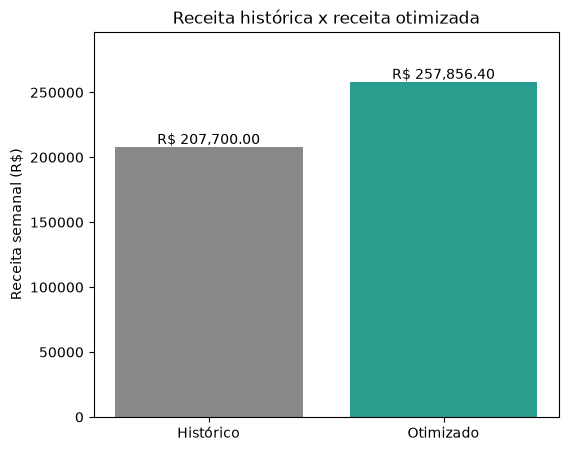

In [11]:
fig, ax = plt.subplots(figsize=(6, 5))

cenarios = ['Histórico', 'Otimizado']
valores = [historical_revenue, optimized_revenue]
cores = ['#888888', '#2a9d8f']

barras = ax.bar(cenarios, valores, color=cores)
ax.set_ylabel('Receita semanal (R$)')
ax.set_title('Receita histórica x receita otimizada')
ax.set_ylim(0, max(valores) * 1.15)
ax.bar_label(barras, labels=[f'R$ {v:,.2f}' for v in valores])

plt.show()

Mesmas 305,6h, redistribuídas de outro jeito - o ganho vem só da realocação, não de mais recurso disponível.

# 8 - Análise crítica

Responda às questões propostas no enunciado:

1. Por que os cirurgiões mais produtivos tendem a receber mais horas?
2. Por que alguns cirurgiões permanecem com poucas horas?
3. Qual é o papel das restrições na solução?
4. Como seu ganho percentual se compara aos aproximadamente 15% reportados no artigo?
5. Quais limitações impedem que a solução matemática seja aplicada de forma automática na gestão real do hospital?

### Sua análise

**1.** Porque a receita é proporcional à produtividade e o total de horas é fixo (305,6h): toda hora que sai de um cirurgião menos produtivo pra um mais produtivo aumenta a receita. No grupo variável, os 5 mais produtivos (15, 16, 8, 19, 7) foram todos ao teto de 31h.

**2.** Porque a soma tem que fechar em exatamente 305,6h - não dá só pra aumentar geral. Os 10 cirurgiões variáveis menos produtivos foram parar no piso de 8h, que é o mínimo da regra 3, não zero.

**3.** Sem o teto de 31h e o piso de 8h, o modelo provavelmente zeraria os menos produtivos e concentraria tudo nos melhores. E a carga fixa do grupo de transplante mostra que restrição de negócio pode custar receita: o cirurgião 17 é o 5º mais produtivo da divisão (R\$870/h) e mesmo assim fica travado em 12h.

**4.** Não - o ganho aqui foi de 24,15%, bem acima dos ~15% do artigo. A principal diferença é que lá os cirurgiões de transplante tinham 8h fixas (aqui são 12h), e o artigo também mantinha fixos outros cirurgiões com foco em pesquisa/ensino que não existem nesta versão simplificada. Com menos gente fora da otimização, o modelo tem mais margem pra levar produtividade ao extremo. O próprio enunciado avisa que os números não precisam bater.

**5.** Produtividade tratada como fixa, quando na prática cai com mais horas alocadas (o artigo original cita o efeito de residentes em treinamento nisso). E o modelo assume fila infinita de pacientes e leitos/equipe sempre disponíveis - premissas que o próprio artigo assume e que raramente seguram na prática.

# 9 - Conclusão

Escreva uma conclusão curta, de aproximadamente 5 a 10 linhas, apresentando:

- o resultado principal;
- o ganho obtido em relação ao histórico;
- o que a solução mostra sobre alocação de recursos escassos;
- uma ressalva importante sobre as simplificações do modelo.

Redistribuindo as mesmas 305,6h semanais, o modelo levaria a receita da divisão de R\$207.700,00 para R\$257.856,40 - um ganho de R\$50.156,40 (24,15%), sem aumentar o recurso disponível. No grupo variável, os mais produtivos foram ao teto de 31h e os menos produtivos ao piso de 8h; o grupo de transplante ficou fixo em 12h independente da produtividade, mostrando que restrição de negócio pode custar receita.

O resultado divergir dos ~15% do artigo original (Kuo et al., 2003) já mostra o quanto pequenas mudanças de restrição - aqui, 12h fixas em vez de 8h, e menos grupos mantidos constantes - afetam o resultado. É um modelo idealizado (produtividade constante, demanda e recursos de apoio ilimitados), útil como apoio à decisão, não como regra automática de gestão hospitalar.